In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler,PolynomialFeatures
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc,hamming_loss,cohen_kappa_score,
    average_precision_score,top_k_accuracy_score,ndcg_score,
    mean_squared_error,mean_absolute_error,median_absolute_error,
    r2_score,mean_squared_log_error,log_loss
)


# Models
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.svm import SVC,SVR
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, ElasticNet,LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import xgboost as xgb


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
# 

## Regression Methods

In [3]:
insurance_df = pd.read_csv("insurance.csv")
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
categorical_cols = ['sex', 'smoker', 'region']
insurance_df = pd.get_dummies(insurance_df, columns=categorical_cols, drop_first=True)

In [5]:
# Train-test split (80-20)
X = insurance_df.drop("charges", axis=1)
y = insurance_df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
# Normalization (StandardScaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))


y_train_scaled = y_train_scaled.ravel()
y_test_scaled = y_test_scaled.ravel()

In [13]:
def train_and_evaluate(model, model_name):
    model.fit(X_train_scaled, y_train_scaled)
    preds = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test_scaled, preds)
    mae = mean_absolute_error(y_test_scaled, preds)
    mape = np.mean(np.abs((y_test_scaled - preds) / y_test_scaled)) * 100
    r2 = r2_score(y_test_scaled, preds)
    msle = mean_squared_log_error(y_test_scaled, preds)
    rmsle = np.sqrt(msle)
    medae = median_absolute_error(y_test_scaled, preds)

    return {
        "Model": model_name,
        "MSE": round(mse, 4),
        "MAE": round(mae, 3),
        "MAPE": round(mape, 3),
        "R2": round(r2, 3),
        "MSLE": round(msle, 3),
        "RMSLE": round(rmsle, 3),
        "MedAE": round(medae, 3),
    }


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "LASSO Regression": Lasso(alpha=0.001),
    "Bayesian Ridge": BayesianRidge(),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Decision Tree Regression": DecisionTreeRegressor(max_depth=6),
    "Support Vector Regression (SVR)": SVR(kernel="rbf", C=100, gamma=0.1),
    "Polynomial Regression (degree=2)": Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linreg', LinearRegression())
    ]),
    "Kernel Regression (KNN Regression)": KNeighborsRegressor(n_neighbors=3),
    "Kernel Ridge (RBF Kernel)": KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1),
    "Kernel Ridge (Polynomial Kernel)": KernelRidge(kernel='polynomial', degree=10, alpha=2.0),
    "Kernel Ridge (Sigmoid Kernel)": KernelRidge(kernel='sigmoid', alpha=1.0),
    "Kernel Ridge (Laplacian Kernel)": KernelRidge(kernel='laplacian', alpha=1.0, gamma=0.1),
}


results = []
for name, model in models.items():
    res = train_and_evaluate(model, name)
    results.append(res)

df_results = pd.DataFrame(results)
df_results

,Model,MSE,MAE,MAPE,R2,MSLE,RMSLE,MedAE
0,Linear Regression,0.0089,0.068,188.082,0.784,0.005,0.072,0.044
1,Ridge Regression,0.0089,0.068,192.685,0.783,0.005,0.072,0.043
2,LASSO Regression,0.0091,0.068,221.572,0.779,0.005,0.072,0.042
3,Bayesian Ridge,0.0089,0.068,189.687,0.783,0.005,0.072,0.044
4,Elastic Net,0.0090,0.068,212.418,0.781,0.005,0.072,0.041
5,Decision Tree Regression,0.0080,0.048,154.183,0.806,0.004,0.067,0.025
6,Support Vector Regression (SVR),0.0106,0.096,531.284,0.743,0.007,0.086,0.099
7,Polynomial Regression (degree=2),0.0055,0.044,139.573,0.867,0.003,0.058,0.026
8,Kernel Regression (KNN Regression),0.0084,0.055,261.751,0.795,0.005,0.072,0.020
9,Kernel Ridge (RBF Kernel),0.0083,0.064,183.843,0.798,0.005,0.069,0.038


# Choose the best regression metric for your dataset and justify.

In [33]:
metrics = ['MSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'RMSLE', 'MedAE']

percent_diff = {}

for m in metrics:
    col_min = df_results[m].min()
    col_max = df_results[m].max()
    percent_increase = ((col_max - col_min) / col_min) * 100
    percent_diff[m] = round(percent_increase, 2)

df_percent_diff = pd.DataFrame.from_dict(percent_diff, orient='index', columns=['% Increase from Min'])
df_percent_diff.sort_values(by='% Increase from Min',ascending=False)


,% Increase from Min
MedAE,395.00
MAPE,280.65
MSLE,133.33
MAE,118.18
MSE,118.18
RMSLE,48.28
R2,22.46


Based on the results, MedAE showed the largest percent change, so it did a good job highlighting performance differences between the models in this dataset. However, I generally prefer R², because it is easier to interpret and gives a clearer idea of how much variance the model explains.

## Explain when each regression model is preferable

#### **1. Linear Regression**
**Use it when:**
- The relationship between features and the target is mostly *linear*  
- The dataset is *small or medium*  
- You want a model that is easy to understand  

**Avoid it when:**  
- There are strong nonlinear patterns  
- Features are highly correlated  

---

#### **2. Ridge Regression**
**Use it when:**
- You have many features  
- You want to reduce *overfitting*  
- Data has some noise  

**Avoid it when:**  
- Relationship is strongly nonlinear  

---

#### **3. LASSO Regression**
**Use it when:**
- You want *feature selection*  
- Some features may not be important  
- You want to reduce overfitting  

**Avoid it when:**  
- Many features are strongly correlated  
- The dataset is very small  

---

#### **4. Bayesian Ridge**
**Use it when:**
- You want a *stable* linear model  
- The dataset is small and noisy  
- You want built-in *regularization*  

**Avoid it when:**  
- Data is strongly nonlinear  

---

#### **5. Elastic Net**
**Use it when:**
- You want both Ridge and LASSO benefits  
- Many features, some important, some not  
- There is correlation between features  

**Avoid it when:**  
- The problem is strongly nonlinear  

---

#### **6. Decision Tree Regression**
**Use it when:**
- The relationship is *nonlinear*  
- You want a model that is simple to interpret  
- You have mixed feature types  

**Avoid it when:**  
- You do not control model depth → overfitting  

---

#### **7. Support Vector Regression (SVR)**
**Use it when:**
- The dataset is *small or medium*  
- You want high accuracy for nonlinear data  
- You want a smooth model with RBF kernel  

**Avoid it when:**  
- The dataset is large → very slow  
- You have many features  

---

#### **8. Polynomial Regression**
**Use it when:**
- The relationship is *smooth and nonlinear*  
- You want a simple way to add nonlinearity  
- The dataset is not too large  

**Avoid it when:**  
- You use high degree → overfitting  
- There are many features  

---

#### **9. Kernel Regression (KNN Regression)**
**Use it when:**
- The dataset is *small or medium*  
- You want to capture complex shapes  
- You don’t need interpretability  

**Avoid it when:**  
- The dataset is large (slow)  
- There are many features 

____

## Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results

kernel trick is a method that used in regression to handle non-linear relationships in data. Instead of transforming the data into a higher-dimensional space directly, it calculates the similarity between points as if they were in that space. This allows models to learn complex patterns efficiently without heavy computation.

# Binary Classification Methods

In [34]:
df_churn = pd.read_csv('Churn.csv')

In [35]:
df_churn['Churn'] = df_churn['Churn'].astype('category')
df_churn['Int\'l Plan'] = df_churn['Int\'l Plan'].astype('category')
df_churn['VMail Plan'] = df_churn['VMail Plan'].astype('category')

cols_to_drop = [
    'Day Charge',
    'Eve Charge',
    'Night Charge',
    'Intl Charge'
]

df_churn = df_churn.drop(columns=cols_to_drop)
df_churn

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,215.5,126,279.1,83,9.9,6,2,False.
3329,WV,68,415,370-3271,no,no,0,231.1,57,153.4,55,191.3,123,9.6,4,3,False.
3330,RI,28,510,328-8230,no,no,0,180.8,109,288.8,58,191.9,91,14.1,6,2,False.
3331,CT,184,510,364-6381,yes,no,0,213.8,105,159.6,84,139.2,137,5.0,10,2,False.


In [36]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   State           3333 non-null   object  
 1   Account Length  3333 non-null   int64   
 2   Area Code       3333 non-null   int64   
 3   Phone           3333 non-null   object  
 4   Int'l Plan      3333 non-null   category
 5   VMail Plan      3333 non-null   category
 6   VMail Message   3333 non-null   int64   
 7   Day Mins        3333 non-null   float64 
 8   Day Calls       3333 non-null   int64   
 9   Eve Mins        3333 non-null   float64 
 10  Eve Calls       3333 non-null   int64   
 11  Night Mins      3333 non-null   float64 
 12  Night Calls     3333 non-null   int64   
 13  Intl Mins       3333 non-null   float64 
 14  Intl Calls      3333 non-null   int64   
 15  CustServ Calls  3333 non-null   int64   
 16  Churn           3333 non-null   category
dtypes: category(3)

In [38]:
df = df_churn.copy()

# encode categorical columns
for col in ["State", "Int'l Plan", "VMail Plan", "Churn"]:
    df[col] = LabelEncoder().fit_transform(df[col])

# drop phone
if "Phone" in df.columns:
    df = df.drop(columns=["Phone"])


X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# KNN tuning (find best K)
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": list(range(1, 21))},
    cv=5,
    scoring="f1"
)
knn_gs.fit(X_train_scaled, y_train)
best_knn = knn_gs.best_estimator_
best_k = knn_gs.best_params_["n_neighbors"]

# Decision Tree tuning (best max_depth)
tree_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": list(range(2, 21))},
    cv=5,
    scoring="f1"
)
tree_gs.fit(X_train, y_train) 
best_tree = tree_gs.best_estimator_
best_depth = tree_gs.best_params_["max_depth"]

print(best_depth,best_k)


6 1


In [40]:
def train_and_evaluate(model, model_name):
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    # probabilities / scores for ROC & AUC
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    elif hasattr(model, "decision_function"):
        try:
            probs = model.decision_function(X_test_scaled)
        except Exception:
            probs = None
    else:
        probs = None

    # basic metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    cm = confusion_matrix(y_test, preds)  

    # ROC AUC (if probs available)
    if probs is not None:
        try:
            fpr, tpr, _ = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)
        except Exception:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    # PR AUC (average precision)
    if probs is not None:
        try:
            pr_auc = average_precision_score(y_test, probs)
        except Exception:
            pr_auc = np.nan
    else:
        pr_auc = np.nan

    # sensitivity / specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4) if not np.isnan(roc_auc) else None,
        "PR_AUC": round(pr_auc, 4) if not np.isnan(pr_auc) else None,
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)
    }


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "SVM (RBF Kernel)": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True),
    f"KNN (k={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    f"Decision Tree (max_depth={best_depth})": DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}


results = []
for name, model in models.items():
    res = train_and_evaluate(model, name)
    results.append(res)

df_results = pd.DataFrame(results)
df_results = df_results[[
    "Model","Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC",
    "Sensitivity","Specificity","TN","FP","FN","TP"
]]

In [41]:
df_results.sort_values("F1", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Sensitivity,Specificity,TN,FP,FN,TP
0,Decision Tree (max_depth=6),0.9235,0.7805,0.6598,0.7151,0.8047,0.6438,0.6598,0.9684,552,18,33,64
1,Random Forest,0.9265,0.8636,0.5876,0.6994,0.8836,0.7862,0.5876,0.9842,561,9,40,57
2,SVM (RBF Kernel),0.9010,0.8039,0.4227,0.5541,0.8895,0.7150,0.4227,0.9825,560,10,56,41
3,KNN (k=1),0.8516,0.4865,0.3711,0.4211,0.6522,0.2720,0.3711,0.9333,532,38,61,36
4,Logistic Regression,0.8591,0.5349,0.2371,0.3286,0.8164,0.4291,0.2371,0.9649,550,20,74,23


## Choose the best classification metric for your dataset and justify

In [43]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC','Sensitivity', 'Specificity']

percent_diff = {}

for m in metrics:
    col_min = df_results[m].min()
    col_max = df_results[m].max()
    percent_increase = ((col_max - col_min) / col_min) * 100
    percent_diff[m] = round(percent_increase, 2)

df_percent_diff = pd.DataFrame.from_dict(percent_diff, orient='index', columns=['% Increase from Min'])
df_percent_diff.sort_values(by='% Increase from Min',ascending=False)


,% Increase from Min
PR_AUC,189.04
Recall,178.28
Sensitivity,178.28
F1,117.62
Precision,77.51
ROC_AUC,36.38
Accuracy,8.80
Specificity,5.45


Based on the metrics, PR_AUC shows the largest change across models, which means it reacts strongly to performance differences and can be a good indicator of how well each model works. However, from experience, F1 is more important in this task, because it captures the trade-off between precision and recall and gives a more balanced view of model performance.

## Explain 3 techniques to regularize the training process for decision trees

One effective way to regularize a decision tree is to set a maximum depth. This prevents the model from growing too deep and memorizing the training data. By stopping the tree early, it focuses on the most important patterns instead of noise, which usually improves generalization on new data.

Another technique is to define a minimum number of samples required to split a node or to be a leaf. When the model cannot split on very small groups of samples, it avoids learning very specific rules that do not apply to the whole dataset. This helps keep the tree simpler and more stable.

Pruning is also a common regularization method. After the tree is fully grown, we remove branches that do not improve performance on validation data. This reduces overfitting and keeps only the parts of the tree that truly help prediction.

## Compare Linear SVM vs Kernel SVM

Linear SVM works well when the data is mostly linearly separable and does not require very complex decision boundaries. It is fast, efficient, and performs strongly on high-dimensional datasets like text or basic structured data. Because it uses a simple hyperplane, training time is low and the model is easier to tune, but it cannot capture more complicated non-linear relationships.

Kernel SVM is more flexible because it uses kernels such as RBF or polynomial to model non-linear patterns. This helps the model fit complex shapes in the data, but it is usually slower and more sensitive to parameters like C and gamma. In general, Linear SVM is a good choice for large datasets and simple structures, while Kernel SVM is better when the data has non-linear patterns that a linear boundary cannot separate.

# Multiclass Classification Methods

In [72]:
seed_df = pd.read_csv('./Seed_Data.csv')
seed_df.head()

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [73]:
X = seed_df.drop(columns=['target'])
y = seed_df['target'].copy()
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_labels = le.classes_.tolist() 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)


In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_classes = len(np.unique(y_enc))

## Tune K for KNN, tune max_depth for tree

In [75]:
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": list(range(1, 21))},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_gs.fit(X_train_scaled, y_train)
best_k = knn_gs.best_params_['n_neighbors']

tree_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": list(range(2, 21))},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
tree_gs.fit(X_train, y_train)
best_depth = tree_gs.best_params_['max_depth']

print(best_k,best_depth)

13 5


In [76]:
def iou_and_dice_from_cm(cm):
    ious = []
    dices = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        union = tp + fp + fn
        iou = tp / union if union > 0 else 0.0
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        ious.append(iou)
        dices.append(dice)
    return np.array(ious), np.array(dices)


# G-Mean as geometric mean of per-class recall
def gmean_from_recalls(recalls):
    eps = 1e-12
    recalls = np.clip(recalls, eps, 1.0)
    return float(np.prod(recalls) ** (1.0 / len(recalls)))

# helper to stringify per-class metrics for DataFrame
def per_class_str(values, labels):
    return ";".join([f"{lab}:{round(val,4)}" for lab, val in zip(labels, values)])


In [ ]:
def train_and_evaluate(model, model_name, top_k=3):
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = None
    if hasattr(model, "predict_proba"):
        try:
            probs = model.predict_proba(X_test_scaled)
        except Exception:
            probs = None
    elif hasattr(model, "decision_function"):
        try:
            dec = model.decision_function(X_test_scaled)
            # convert decision_function to pseudo-prob via softmax if it's 2D or 1D
            if dec.ndim == 1:
                # binary-like
                probs = np.vstack([1/(1+np.exp(-dec)), 1/(1+np.exp(dec))]).T
            else:
                # apply softmax
                e = np.exp(dec - np.max(dec, axis=1, keepdims=True))
                probs = e / e.sum(axis=1, keepdims=True)
        except Exception:
            probs = None

    # basic metrics
    acc = accuracy_score(y_test, preds)
    prec_per_class = precision_score(y_test, preds, average=None, zero_division=0)
    rec_per_class = recall_score(y_test, preds, average=None, zero_division=0)

    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)
    f1_micro = f1_score(y_test, preds, average='micro', zero_division=0)
    f1_weighted = f1_score(y_test, preds, average='weighted', zero_division=0)

    # log loss (needs probs)
    logloss_val = None
    if probs is not None:
        try:
            logloss_val = log_loss(y_test, probs)
        except Exception:
            logloss_val = None

    # Kappa
    try:
        kappa = cohen_kappa_score(y_test, preds)
    except Exception:
        kappa = None

    # confusion matrix
    cm = confusion_matrix(y_test, preds, labels=np.arange(n_classes))

    # IoU & Dice per-class
    ious, dices = iou_and_dice_from_cm(cm)

    # Top-K accuracy & ndcg (needs probs)
    topk_acc = None
    ndcg = None
    if probs is not None:
        try:
            topk_acc = top_k_accuracy_score(y_test, probs, k=top_k, labels=np.arange(n_classes))
        except Exception:
            topk_acc = None
        try:
            y_true_onehot = np.zeros_like(probs)
            y_true_onehot[np.arange(len(y_test)), y_test] = 1
            ndcg = ndcg_score(y_true_onehot, probs)
        except Exception:
            ndcg = None

    # Hamming loss
    try:
        ham = hamming_loss(y_test, preds)
    except Exception:
        ham = None

    # G-Mean
    gmean = gmean_from_recalls(rec_per_class)

    # prepare return dict
    out = {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "LogLoss": round(logloss_val, 4) if logloss_val is not None else None,
        "Kappa": round(kappa, 4) if kappa is not None else None,
        "F1_macro": round(f1_macro, 4),
        "F1_micro": round(f1_micro, 4),
        "F1_weighted": round(f1_weighted, 4),
        "Top-{}-Acc".format(top_k): round(topk_acc, 4) if topk_acc is not None else None,
        "NDCG": round(ndcg, 4) if ndcg is not None else None,
        "Hamming": round(ham, 4) if ham is not None else None,
        "GMean": round(gmean, 4),
        "Confusion_Matrix": cm.tolist(),
        "Precision_per_class": per_class_str(prec_per_class, class_labels),
        "Recall_per_class": per_class_str(rec_per_class, class_labels),
        "IoU_per_class": per_class_str(ious, class_labels),
        "Dice_per_class": per_class_str(dices, class_labels)
    }
    return out


### Define Models

In [80]:
models = {
    "Logistic (OVR)": LogisticRegression(multi_class='ovr', solver='liblinear', max_iter=1000),
    "Logistic (multinomial)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    "SVM (Linear, OVR)": SVC(kernel='linear', decision_function_shape='ovr', probability=True),
    "Kernel SVM (RBF, OVO)": SVC(kernel='rbf', decision_function_shape='ovo', probability=True),
    f"KNN (k={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    f"Decision Tree (max_depth={best_depth})": DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

### Run loop & collect results

In [ ]:
results = []
for name, model in models.items():
    res = train_and_evaluate(model, name, top_k=3)
    results.append(res)

df_results = pd.DataFrame(results)
cols_order = [
    "Model", "Accuracy", "LogLoss", "Kappa",
    "F1_macro", "F1_micro", "F1_weighted",
    "Top-3-Acc", "NDCG", "Hamming", "GMean",
    "Precision_per_class", "Recall_per_class",
    "IoU_per_class", "Dice_per_class", "Confusion_Matrix"
]
existing = [c for c in cols_order if c in df_results.columns]
df_results = df_results[existing + [c for c in df_results.columns if c not in existing]]
df_results

,Model,Accuracy,LogLoss,Kappa,F1_macro,F1_micro,F1_weighted,Top-3-Acc,NDCG,Hamming,GMean,Precision_per_class,Recall_per_class,IoU_per_class,Dice_per_class,Confusion_Matrix
0,Logistic (OVR),0.8810,0.2529,0.8214,0.8731,0.8810,0.8731,1.0,0.9561,0.1190,0.8631,0:1.0;1:0.8235;2:0.875,0:0.6429;1:1.0;2:1.0,0:0.6429;1:0.8235;2:0.875,0:0.7826;1:0.9032;2:0.9333,"[[9, 3, 2], [0, 14, 0], [0, 0, 14]]"
1,Logistic (multinomial),0.8810,0.2454,0.8214,0.8731,0.8810,0.8731,1.0,0.9561,0.1190,0.8631,0:1.0;1:0.875;2:0.8235,0:0.6429;1:1.0;2:1.0,0:0.6429;1:0.875;2:0.8235,0:0.7826;1:0.9333;2:0.9032,"[[9, 2, 3], [0, 14, 0], [0, 0, 14]]"
2,"SVM (Linear, OVR)",0.8810,0.3082,0.8214,0.8731,0.8810,0.8731,1.0,0.9561,0.1190,0.8631,0:1.0;1:0.875;2:0.8235,0:0.6429;1:1.0;2:1.0,0:0.6429;1:0.875;2:0.8235,0:0.7826;1:0.9333;2:0.9032,"[[9, 2, 3], [0, 14, 0], [0, 0, 14]]"
3,"Kernel SVM (RBF, OVO)",0.9048,0.2078,0.8571,0.9000,0.9048,0.9000,1.0,0.9649,0.0952,0.8939,0:1.0;1:0.875;2:0.875,0:0.7143;1:1.0;2:1.0,0:0.7143;1:0.875;2:0.875,0:0.8333;1:0.9333;2:0.9333,"[[10, 2, 2], [0, 14, 0], [0, 0, 14]]"
4,KNN (k=13),0.8810,0.2169,0.8214,0.8766,0.8810,0.8766,1.0,0.9561,0.1190,0.8721,0:0.9091;1:0.8667;2:0.875,0:0.7143;1:0.9286;2:1.0,0:0.6667;1:0.8125;2:0.875,0:0.8;1:0.8966;2:0.9333,"[[10, 2, 2], [1, 13, 0], [0, 0, 14]]"
5,Decision Tree (max_depth=5),0.8810,4.2909,0.8214,0.8766,0.8810,0.8766,1.0,0.9483,0.1190,0.8721,0:0.9091;1:0.8667;2:0.875,0:0.7143;1:0.9286;2:1.0,0:0.6667;1:0.8125;2:0.875,0:0.8;1:0.8966;2:0.9333,"[[10, 2, 2], [1, 13, 0], [0, 0, 14]]"
6,Random Forest,0.9048,0.2156,0.8571,0.9007,0.9048,0.9007,1.0,0.9649,0.0952,0.8939,0:1.0;1:0.9333;2:0.8235,0:0.7143;1:1.0;2:1.0,0:0.7143;1:0.9333;2:0.8235,0:0.8333;1:0.9655;2:0.9032,"[[10, 1, 3], [0, 14, 0], [0, 0, 14]]"
7,XGBoost,0.9048,0.2301,0.8571,0.9000,0.9048,0.9000,1.0,0.9649,0.0952,0.8939,0:1.0;1:0.875;2:0.875,0:0.7143;1:1.0;2:1.0,0:0.7143;1:0.875;2:0.875,0:0.8333;1:0.9333;2:0.9333,"[[10, 2, 2], [0, 14, 0], [0, 0, 14]]"
8,AdaBoost,0.8810,0.9330,0.8214,0.8731,0.8810,0.8731,1.0,0.9561,0.1190,0.8631,0:1.0;1:0.875;2:0.8235,0:0.6429;1:1.0;2:1.0,0:0.6429;1:0.875;2:0.8235,0:0.7826;1:0.9333;2:0.9032,"[[9, 2, 3], [0, 14, 0], [0, 0, 14]]"


### Choose the best multiclass-classification metric for your dataset and justify.

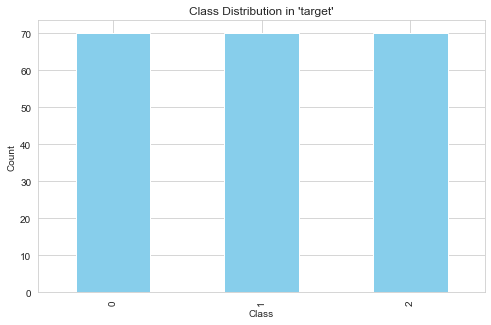

In [90]:
target_col = 'target'
counts = seed_df[target_col].value_counts()
percent = seed_df[target_col].value_counts(normalize=True) * 100
plt.figure(figsize=(8,5))
counts.plot(kind='bar', color='skyblue')
plt.title(f"Class Distribution in '{target_col}'")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

For this dataset, Accuracy is the most appropriate metric because all three classes are perfectly balanced with equal numbers of samples. This balance ensures that Accuracy reliably reflects the overall performance of the model without being biased toward any class. Additionally, F1-Macro can be used as a complementary metric to consider the trade-off between precision and recall for each class, but in this case, it will give results very similar to Accuracy.

## Explain how KNN and Decision Trees can be extended to multi-label classification problems.

KNN and Decision Trees are naturally designed for single-label classification, but they can be extended to multi-label problems using some strategies. For KNN, the most common approach is Binary Relevance, where a separate KNN classifier is trained for each label independently, and a new sample gets predicted for all labels simultaneously. Another approach is Label Powerset, which treats every unique combination of labels as a single class and applies standard KNN on these combined classes. For Decision Trees, a similar strategy is used: either train one tree per label (Binary Relevance) or transform the multi-label problem into a single-label problem using Label Powerset. Some tree-based algorithms, like Random Forests or Gradient Boosting, can also be adapted to multi-label classification by using specialized loss functions (e.g., multi-label entropy or log-loss) that evaluate all labels at once.

____

Suppose we have a multi-label classification problem in football, where each player can belong to some of these 4 classes:

- **Class 1:** The player has played for the national team before  
- **Class 2:** The player has a history of heart problems  
- **Class 3:** The player had previous knee injuries  
- **Class 4:** The player has been a team captain in the past  

What **accuracy metric** would you use to best evaluate a classification algorithm that predicts the above classes based on data from each player, and **why**?  

For this multi-label football problem, the best metric would be **Hamming Loss** or its complement, **Hamming Score (accuracy per label)**.  

The reason is that **each player can belong to multiple classes simultaneously**, so traditional Accuracy (exact match of all labels) can be too strict: if a model predicts 3 out of 4 labels correctly, exact-match Accuracy would count it as 0, which is misleading. **Hamming Loss** measures the fraction of misclassified labels over all labels and all samples, giving a more balanced view of performance for each individual label. This way, the metric reflects how well the algorithm predicts each class independently while handling the multi-label nature of the problem.  

Optionally, **F1-Macro or F1-Weighted per label** can also complement Hamming Loss to capture the trade-off between precision and recall for each class.






